_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: yellow'>Frauke von der Haar, Urmi Jana </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Neural Data Science Project — Spike Inference

## Inferring spiking activity from calcium imaging data using deep learning

In this project you will train your own deep network to infer neuronal spiking activity from calcium imaging ΔF/F traces. You will work with ground truth data from simultaneous calcium imaging and electrophysiology recordings, preprocess it for training, build and train a neural network, and evaluate your model on held-out neurons.

You are free to use tools, resources and libraries as you see fit. Use comments and markdown cells to document your thought process and to explain your reasoning. We encourage you to compare different algorithms or to implement state of the art solutions. The notebook should be self contained, although you may offload some functions to a `utils.py`. The notebook should be concluded with a final summary / conclusions section.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample
from scipy.stats import pearsonr

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

## Context

### Calcium imaging and spike inference

Two-photon calcium imaging records neural activity by measuring fluorescence of genetically encoded calcium indicators (e.g. GCaMP6f, GCaMP6s). When a neuron fires an action potential, calcium flows into the cell, causing the indicator to fluoresce more brightly. The resulting signal — expressed as **ΔF/F** (relative fluorescence change) — is a noisy, temporally smoothed version of the true spiking activity:

- A single action potential produces a fast rise (~50 ms) followed by a slow exponential decay (~200–1000 ms, depending on the indicator)
- The signal is corrupted by shot noise, neuropil contamination, and motion artifacts
- Multiple spikes in quick succession sum nonlinearly

**Spike inference** (also called deconvolution) is the inverse problem of recovering the underlying spike times or spike rates from the observed ΔF/F traces.

### Cascade as a reference

In this project you will train your own neural network for the task of spike inference, similar to what was done in [**Cascade**](https://github.com/HelmchenLabSoftware/Cascade) (Rupprecht et al., *Nature Neuroscience*, 2021). Cascade trains a simple 1D convolutional network (~50k parameters) on a large database of simultaneous calcium imaging and electrophysiology recordings. A key part of their approach is a noise-matched training procedure that resamples the ground truth data to match the noise level and frame rate of any target recording, making the trained models robust across different experimental conditions. Cascade also provides pretrained models for common configurations that can serve as performance baselines.

You can use their code, preprocessing routines, and pretrained models as a reference. The PyTorch implementation is available at [CascadeTorch](https://github.com/PTRRupprecht/CascadeTorch).

**Paper:** Rupprecht P, Carta S, Hoffmann A, Echizen M, Blot A, Kwan AC, Dan Y, Hofer SB, Kitamura K, Helmchen F\*, Friedrich RW\*. *A database and deep learning toolbox for noise-optimized, generalized spike inference from calcium imaging.* Nature Neuroscience (2021). [Link](https://www.nature.com/articles/s41593-021-00895-5)

### The data

The file `spike_inference_data.npz` contains ground truth recordings from simultaneous calcium imaging and electrophysiology. Each recording provides:

| Field | Description |
|---|---|
| `dff` | ΔF/F fluorescence trace (1D float array) |
| `t` | Time vector in seconds (1D float array) |
| `spikes` | Action potential times in seconds (1D float array) |
| `frame_rates` | Imaging frame rate in Hz (scalar) |
| `datasets` | Source dataset identifier (string) |

The data is split into:

- **Training recordings** (`train_*`): Use these to build your preprocessing pipeline and train your network. They come from 4 ground truth datasets recorded with GCaMP6f and GCaMP6s in mouse visual cortex.
- **Test recordings** (`test_*`): A held-out dataset for final evaluation. Do not use these for training.

All recordings were obtained at ~60 Hz and can be resampled to a lower frame rate (e.g. 30 Hz) during preprocessing.

In [5]:
# load data
def load_data(path="./data"):
    data = np.load(path + "/spike_inference_data.npz", allow_pickle=True)
    return dict(data)

def print_info(data):
    for key in sorted(data.keys()):
        arr = data[key]
        if arr.dtype == object:
            print(f"  [{key:25s}]  {arr.shape}  (variable-length arrays)")
        else:
            print(f"  [{key:25s}]  {arr.shape}  dtype={arr.dtype}")

data = load_data()

print("Overview of the data")
print_info(data)
print(f"\nTraining datasets: {list(data['train_dataset_names'])}")
print(f"Test datasets:     {list(data['test_dataset_names'])}")
print(f"Training recordings: {len(data['train_dff'])}")
print(f"Test recordings:     {len(data['test_dff'])}")

Overview of the data
  [test_dataset_names       ]  (1,)  dtype=<U17
  [test_datasets            ]  (9,)  (variable-length arrays)
  [test_dff                 ]  (9,)  (variable-length arrays)
  [test_filenames           ]  (9,)  (variable-length arrays)
  [test_frame_rates         ]  (9,)  dtype=float64
  [test_spikes              ]  (9,)  (variable-length arrays)
  [test_t                   ]  (9,)  (variable-length arrays)
  [train_dataset_names      ]  (4,)  dtype=<U36
  [train_datasets           ]  (83,)  (variable-length arrays)
  [train_dff                ]  (83,)  (variable-length arrays)
  [train_filenames          ]  (83,)  (variable-length arrays)
  [train_frame_rates        ]  (83,)  dtype=float64
  [train_spikes             ]  (83,)  (variable-length arrays)
  [train_t                  ]  (83,)  (variable-length arrays)

Training datasets: [np.str_('DS09-GCaMP6f-m-V1'), np.str_('DS10-GCaMP6f-m-V1-neuropil-corrected'), np.str_('DS14-GCaMP6s-m-V1'), np.str_('DS15-GCaMP6s-m-V

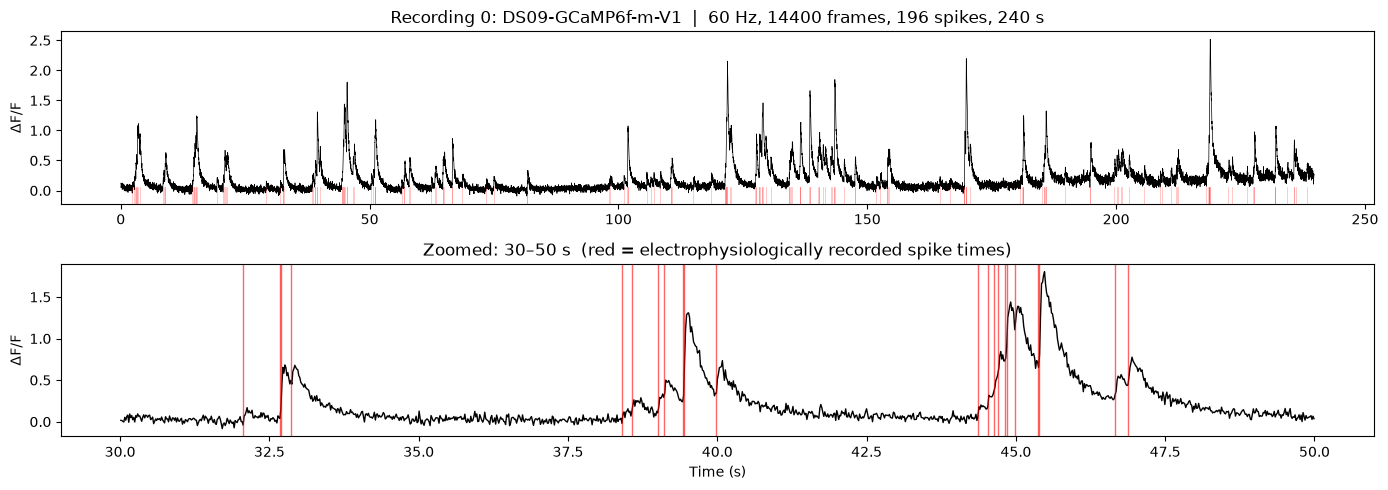

In [6]:
# Visualize an example training recording
idx = 0  # change this to browse different recordings
dff = data['train_dff'][idx]
t = data['train_t'][idx]
spikes = data['train_spikes'][idx]
fr = data['train_frame_rates'][idx]
ds_name = str(data['train_datasets'][idx])

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Full trace
axes[0].plot(t, dff, 'k', linewidth=0.5)
for sp in spikes:
    axes[0].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)
axes[0].set_ylabel('ΔF/F')
axes[0].set_title(f'Recording {idx}: {ds_name}  |  {fr:.0f} Hz, {len(dff)} frames, '
                  f'{len(spikes)} spikes, {t[-1]:.0f} s')

# Zoomed window
t0, t1 = 30, 50
m = (t >= t0) & (t <= t1)
axes[1].plot(t[m], dff[m], 'k', linewidth=1)
for sp in spikes[(spikes >= t0) & (spikes <= t1)]:
    axes[1].axvline(sp, color='red', alpha=0.6, linewidth=1)
axes[1].set_ylabel('ΔF/F')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Zoomed: {t0}–{t1} s  (red = electrophysiologically recorded spike times)')

plt.tight_layout()
plt.show()

## Research question

<span style='background: yellow'>
Investigating and Mitigating Domain Shift in Deep Learning-Based Spike Inference Across Calcium Indicators
Does spike inference exhibit asymmetric generalization between GCaMP6f and GCaMP6s?
Can mixed-indicator training reduce this domain shift? How does the model architecture affect spike inference performance?
</span>

Some possible directions (pick one, or formulate your own):

1. **Train a spike inference network and evaluate its generalization.** Build a preprocessing pipeline (resampling, noise augmentation, windowing, target smoothing), train a neural net, and evaluate on the held-out test set. How does performance depend on the training data composition and noise level?

2. **Compare architectures.** Implement at least two different network architectures (e.g. the Cascade default, a deeper/shallower variant, one with skip connections or batch normalization). Which design choices matter most for spike inference performance?

3. **How does temporal smoothing of the ground truth affect inference quality?** Train models with different smoothing kernels (e.g. 25, 50, 100, 200 ms) and evaluate the trade-off between temporal precision and robustness. Optionally compare symmetric vs. causal smoothing kernels.

4. **How well does a network trained on one indicator generalize to another?** Train on GCaMP6f data only and test on GCaMP6s (or vice versa). How much does indicator-specific training improve performance?

Implement all steps necessary to answer your question. Think of: preprocessing, model design, training, evaluation, and visualization. The notebook should be concluded with a summary / conclusions section.

# Delete when finished!


In [7]:

%load_ext autoreload
%autoreload 2

import utils
import warnings
import importlib
%reload_ext autoreload
warnings.warn("Test ")

importlib.reload(utils)
print(dir(utils))

['Any', 'Cascade1DCNN', 'DataLoader', 'Dict', 'List', 'Optional', 'TensorDataset', 'Tuple', 'WeightedRandomSampler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_shift_and_truncate', 'apply_lag', 'augment_train_noise', 'bin_discrete_spikes', 'bounded_cross_correlation_alignment', 'cheby1', 'compute_dynamic_dff', 'compute_noise_ceiling', 'correct_dff_baseline_drift', 'create_balanced_dataloader', 'evaluate_predictions', 'f1_score', 'filter_by_indicator', 'find_best_lag', 'fit_dataset_level_lag', 'gaussian_filter1d', 'generate_sliding_windows', 'get_dynamic_snr_threshold', 'get_indicator', 'interp1d', 'nn', 'np', 'partition_recordings', 'pearsonr', 'percentile_filter', 'robust_quality_control', 'scale_features', 'smooth_spike_train', 'sosfiltfilt', 'standardize_trace', 'torch', 'uniform_filter1d', 'warnings']


/tmp/ipykernel_5719/3632930296.py:8: UserWarning: Test 
  warnings.warn("Test ")


## Data exploration 

In [8]:
from utils import  get_indicator

# Minimun frame rate
print(f"Training FR - Min: {np.min(data['train_frame_rates']):.2f} Hz, Max: {np.max(data['train_frame_rates']):.2f} Hz")
print(f"Testing FR - Min: {np.min(data['train_frame_rates']):.2f} Hz, Max: {np.max(data['test_frame_rates']):.2f} Hz")

test_ds_names = sorted(set(str(d) for d in data['test_dataset_names']))
train_ds_names = sorted(set(str(d) for d in data['train_dataset_names']))

indicator_of = {'DS09': '6f', 'DS10': '6f', 'DS14': '6s', 'DS15': '6s', 'DS16': '6s'}



train_indicators = sorted(set(get_indicator(d) for d in train_ds_names))
test_indicators  = sorted(set(get_indicator(d) for d in test_ds_names))
print("Train indicators:", train_indicators)
print("Test indicators: ", test_indicators)

print("Train datasets:", train_ds_names)
print("Test datasets: ", test_ds_names)

from collections import Counter
print(Counter(str(d) for d in data['test_datasets']))  # per-recording, not just unique names


from collections import defaultdict

fr_by_dataset = defaultdict(list)
for ds, fr in zip(data['train_datasets'], data['train_frame_rates']):
    fr_by_dataset[str(ds)].append(fr)

for ds, frs in sorted(fr_by_dataset.items()):
    print(f"{ds}: n={len(frs)}, FR range=[{min(frs):.1f}, {max(frs):.1f}]")




Training FR - Min: 59.06 Hz, Max: 179.86 Hz
Testing FR - Min: 59.06 Hz, Max: 59.10 Hz
Train indicators: ['6f', '6s']
Test indicators:  ['6s']
Train datasets: ['DS09-GCaMP6f-m-V1', 'DS10-GCaMP6f-m-V1-neuropil-corrected', 'DS14-GCaMP6s-m-V1', 'DS15-GCaMP6s-m-V1']
Test datasets:  ['DS16-GCaMP6s-m-V1']
Counter({'DS16-GCaMP6s-m-V1': 9})
DS09-GCaMP6f-m-V1: n=33, FR range=[60.1, 60.1]
DS10-GCaMP6f-m-V1-neuropil-corrected: n=23, FR range=[158.3, 179.9]
DS14-GCaMP6s-m-V1: n=18, FR range=[60.1, 60.1]
DS15-GCaMP6s-m-V1: n=9, FR range=[59.1, 59.1]


 📝 **Personal note.** project guideline recommends downsampling to 30 HZ , but why not to just the min Framrerate
 built in noise filter
 computational efficiency 

# Overall Pipeline

All recordings undergo the same preprocessing sequence before model training. During evaluation, held-out datasets pass through the identical preprocessing pipeline, but any parameters that require fitting (e.g., feature-scaling statistics or noise augmentation targets) are estimated exclusively from the corresponding training fold to prevent information leakage.

## Phase 0 – Dataset Inspection

| Step | What happens | Function(s) |
|---|---|---|

| 0a | Verify the composition of the official held-out test set | Notebook |

---

# Preprocessing Pipeline

| Step | What happens | Function |
|---|---|---|
| 1 | Resample every ΔF/F trace onto a uniform 30 Hz temporal grid | `standardize_trace` |
| 2 | Convert continuous spike timestamps into discrete per-frame spike counts | `bin_discrete_spikes` |
| 2b | Evaluate potential hardware synchronization lag (measured but deliberately not corrected to avoid confounding indicator kinetics) | `fit_dataset_level_lag`, `bounded_cross_correlation_alignment` |
| 3 | Remove slow baseline drift from the already-computed ΔF/F traces | `correct_dff_baseline_drift` |
| 4 | Exclude recordings with insufficient spike activity or poor signal quality | `robust_quality_control` |
| 5 | Transform discrete spike counts into continuous Gaussian-smoothed firing-rate targets (Hz) | `smooth_spike_train` |

---

# Cross-Validation and Training Pipeline

| Step | What happens |
|---|---|
| 6 | Construct Leave-One-Dataset-Out (LODO) folds, holding out one source dataset at a time |
| 7a | For each LODO fold, optionally augment training recordings to match a common noise ceiling |
| 7b | Convert continuous recordings into fixed-length CNN input windows |
| 7c | Z-score inputs using statistics computed exclusively from the current training fold |
| 7d | Train and evaluate the network under multiple random seeds to estimate performance variability |

---

# Evaluation and Analysis

| Step | What happens |
|---|---|
| 8 | Aggregate performance across LODO folds and random seeds (mean ± standard deviation) |
| 9 | Estimate the within-indicator transfer floor by measuring cross-dataset generalization while keeping the calcium indicator fixed |
| 10 | Compare within- and cross-indicator transfer performance (`6f→6f`, `6s→6s`, `6f→6s`, `6s→6f`) to isolate the contribution of indicator-specific domain shift |

---

## Evaluation Logic

The LODO evaluation framework is designed to separate dataset-specific variation from calcium-indicator-specific domain shift:

- **Within-indicator transfer** (`6f→6f`, `6s→6s`) estimates the expected performance limit when the indicator remains unchanged but the recording dataset differs.
- **Cross-indicator transfer** (`6f→6s`, `6s→6f`) measures the additional challenge introduced by indicator kinetics.
- The difference between these conditions quantifies the contribution of indicator-specific domain shift relative to general dataset variation.

This design prevents information leakage, ensures identical preprocessing for training and evaluation data, and directly addresses the central research question of how robust spike inference models are across calcium indicators.

### Step 1 — Temporal Standardization
`standardize_trace()` · `utils.py`

**Problem.** Raw ΔF/F traces aren't sampled at a perfectly uniform rate, and exact frame rates vary slightly across recordings (~59–61 Hz here). A 1D-CNN needs the same physical duration to be represented by the same number of frames in every recording, or it can't learn one consistent temporal kernel (e.g. for the ~50 ms GCaMP rise time).

**Solution.** Every trace is resampled onto a single uniform 30 Hz grid. When a recording needs downsampling, an 8th-order Chebyshev Type I low-pass filter is applied first (zero-phase, via `sosfiltfilt`), then linearly interpolated onto the exact target grid. If the native rate is already ≤ 30 Hz, filtering is skipped since there's no aliasing risk.

**Why.** Resampling without filtering first lets high-frequency content (shot noise, motion artifacts) fold back down into the calcium-transient band, corrupting the trace permanently.

**Why not.** Cutting off exactly at the new Nyquist frequency would still leak some aliased energy, since Chebyshev filters roll off gradually rather than instantly — hence the small safety margin below it.


In [9]:
from utils import standardize_trace

TARGET_FS = 30.0  # Hz - global standard for the whole project

phase1_data = {}

print(f"Resampling continuous traces to {TARGET_FS} Hz...")

for idx in range(len(data['train_dff'])):
    raw_dff = data['train_dff'][idx]
    raw_t = data['train_t'][idx]

    # Anti-aliased resampling onto the uniform target grid
    dff_res, t_res = standardize_trace(dff=raw_dff, t=raw_t, target_fs=TARGET_FS)

    # Keep everything needed for the next preprocessing steps together,
    # keyed by recording index so nothing gets misaligned downstream.
    phase1_data[idx] = {
        'dff': dff_res,                              # resampled dF/F trace
        'frame_times': t_res,                        # resampled, uniform time vector
        'spikes': data['train_spikes'][idx],         # RAW spike times (point events - not resampled)
        'dataset': str(data['train_datasets'][idx]),
        'filename': str(data['train_filenames'][idx]),
        'orig_frame_rate': data['train_frame_rates'][idx],
    }

print(f"Successfully resampled {len(phase1_data)} recordings.")
print(f"Recording 0 - Original shape: {data['train_dff'][0].shape} "
      f"(~{data['train_frame_rates'][0]:.1f} Hz)")
print(f"Recording 0 - New shape:      {phase1_data[0]['dff'].shape} ({TARGET_FS} Hz)")


Resampling continuous traces to 30.0 Hz...
Successfully resampled 83 recordings.
Recording 0 - Original shape: (14400,) (~60.1 Hz)
Recording 0 - New shape:      (7193,) (30.0 Hz)


> 📝 **Personal note.** The original version of this function returned `dff_standard,` — a trailing comma that silently turned the return value into a 1-tuple and dropped `t_standard` entirely. Python doesn't complain about that at all;
>  worth double-checking multi-return functions actually unpack the way expected, especially after a refactor.
>
>  — worth remembering *why* you filter before you downsample, not just that you do.

In [10]:
### Sanity check 

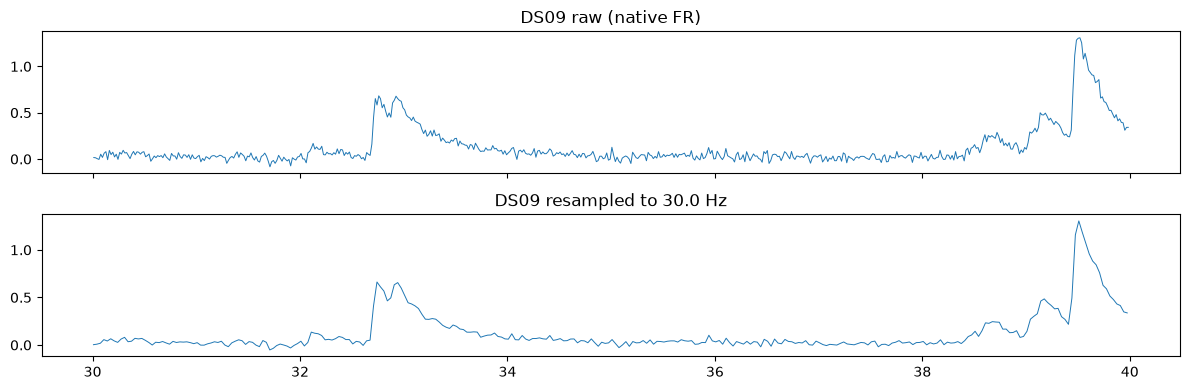

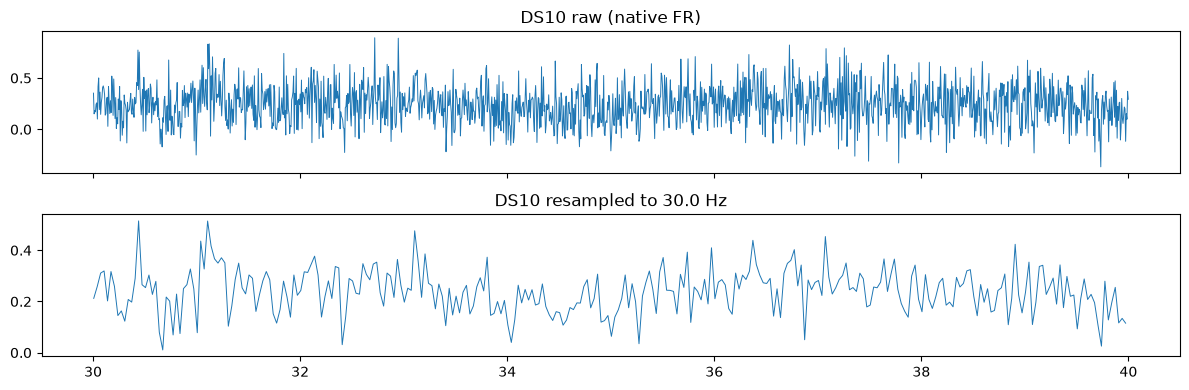

In [11]:
# Compare a DS09 (typical 60 Hz ) and DS10 (outlier 170 Hz ) recording before/after resampling
for ds_check in ['DS09', 'DS10']:
    idx = next(i for i in range(len(data['train_dff']))
               if str(data['train_datasets'][i]).startswith(ds_check))
    raw_dff, raw_t = data['train_dff'][idx], data['train_t'][idx]
    dff_res, t_res = standardize_trace(dff=raw_dff, t=raw_t, target_fs=TARGET_FS)

    fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
    m_raw = (raw_t >= 30) & (raw_t <= 40)
    m_res = (t_res >= 30) & (t_res <= 40)
    axes[0].plot(raw_t[m_raw], raw_dff[m_raw], lw=0.7); axes[0].set_title(f'{ds_check} raw (native FR)')
    axes[1].plot(t_res[m_res], dff_res[m_res], lw=0.7);  axes[1].set_title(f'{ds_check} resampled to {TARGET_FS} Hz')
    plt.tight_layout(); plt.show()

In [12]:
def noise_level(dff, fr):
    return np.median(np.abs(np.diff(dff))) / np.sqrt(fr)

rows = []
for idx in range(len(data['train_dff'])):
    ds  = str(data['train_datasets'][idx])
    dff = data['train_dff'][idx]
    fr  = data['train_frame_rates'][idx]
    rows.append(dict(dataset=ds, noise_level=noise_level(dff, fr),
                      peak99=np.percentile(dff, 99), median=np.median(dff)))

df_noise = pd.DataFrame(rows)
print(df_noise.groupby('dataset')['noise_level'].describe())

                                      count      mean       std       min  \
dataset                                                                     
DS09-GCaMP6f-m-V1                      33.0  0.004055  0.001224  0.002582   
DS10-GCaMP6f-m-V1-neuropil-corrected   23.0  0.004631  0.002171  0.002680   
DS14-GCaMP6s-m-V1                      18.0  0.005293  0.001628  0.002898   
DS15-GCaMP6s-m-V1                       9.0  0.006926  0.002211  0.004789   

                                           25%       50%       75%       max  
dataset                                                                       
DS09-GCaMP6f-m-V1                     0.003151  0.003819  0.004165  0.007334  
DS10-GCaMP6f-m-V1-neuropil-corrected  0.003082  0.004235  0.005405  0.012967  
DS14-GCaMP6s-m-V1                     0.003705  0.005564  0.006147  0.008802  
DS15-GCaMP6s-m-V1                     0.005329  0.006093  0.008026  0.010522  


#### Sanity check -- does DS10's native frame rate introduce an indicator-correlated confound?

DS10 (100% GCaMP6f) was recorded natively at 158-180 Hz, vs. ~60 Hz for DS09/DS14/DS15.
Every recording is downsampled to the same `TARGET_FS = 30 Hz` with an anti-alias filter
cutoff fixed at `0.9 * TARGET_FS / 2` regardless of source -- but that means DS10 is having a
much larger share of its own native bandwidth discarded than the other three datasets, purely
as a side effect of its own acquisition rate, not anything biological. Because DS10 is
entirely one indicator, this is the same category of risk as the lag-correction confound
already identified and avoided in Step 2b: an indicator-correlated *preprocessing* difference
that could be mistaken for an indicator-correlated *biological* one. This cell just makes the
asymmetry visible -- it doesn't attempt to correct for it, since what (if anything) to do
about it is a judgment call, not a bug fix.

Fixed AA filter cutoff for every recording: 13.5 Hz

                                     native_fr                            \
                                         count        mean           std   
dataset                                                                    
DS09-GCaMP6f-m-V1                         33.0   60.060060  1.012679e-14   
DS10-GCaMP6f-m-V1-neuropil-corrected      23.0  160.079083  4.870744e+00   
DS14-GCaMP6s-m-V1                         18.0   60.060060  9.118948e-15   
DS15-GCaMP6s-m-V1                          9.0   59.079312  2.439974e-02   

                                                                          \
                                             min         25%         50%   
dataset                                                                    
DS09-GCaMP6f-m-V1                      60.060060   60.060060   60.060060   
DS10-GCaMP6f-m-V1-neuropil-corrected  158.280441  158.280441  158.280441   
DS14-GCaMP6s-m-V1                 

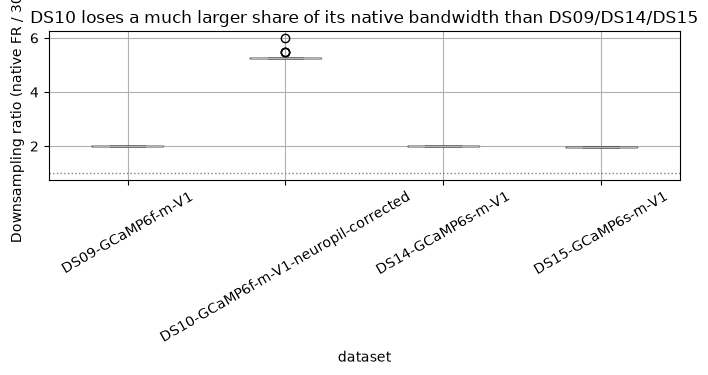

In [13]:
downsample_stats = []
for idx in range(len(data['train_dff'])):
    ds = str(data['train_datasets'][idx])
    fr = data['train_frame_rates'][idx]
    downsample_stats.append(dict(
        dataset=ds,
        indicator=get_indicator(ds),
        native_fr=fr,
        downsample_ratio=fr / TARGET_FS,
    ))

df_downsample = pd.DataFrame(downsample_stats)
print(f"Fixed AA filter cutoff for every recording: {0.9 * TARGET_FS / 2:.1f} Hz\n")
print(df_downsample.groupby('dataset')[['native_fr', 'downsample_ratio']].describe())

fig, ax = plt.subplots(figsize=(7, 4))
df_downsample.boxplot(column='downsample_ratio', by='dataset', ax=ax, rot=30)
ax.set_ylabel('Downsampling ratio (native FR / 30 Hz)')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
plt.suptitle('')
plt.title('DS10 loses a much larger share of its native bandwidth than DS09/DS14/DS15')
plt.tight_layout()
plt.show()

### Step 2 — Discrete Event Binning
`bin_discrete_spikes()` · `utils.py`

**Problem.** Spikes are timestamped continuously (electrophysiology clock); the resampled ΔF/F is discrete (camera frames). Every spike has to be assigned to exactly one frame, with none silently lost or double-counted.

**Solution.** Build bin edges at the midpoints between consecutive frame timestamps (plus extrapolated edges at the two ends), then histogram the spike times into those edges.

**Why.** Midpoint edges give the least-biased assignment when frame intervals aren't perfectly uniform, and they let spike conservation be checked explicitly — the sum of the binned counts must equal the number of spikes that actually fall inside the recording window.

**Why not.** A fixed-width bin (e.g. `[frame, frame + dt)`) is simpler but systematically biases spikes near a boundary toward the earlier frame; midpoint edges center each bin on its own frame instead.


### Step 2b — Hardware Lag Correction: Evaluated and Skipped
`fit_dataset_level_lag()` / `bounded_cross_correlation_alignment()` · `utils.py` — *available, not used here*

**Problem.** Optical and electrical acquisition systems can have a small, fixed synchronization offset. `utils.py` provides two ways to estimate and correct it: a per-recording fit and a more robust per-source-dataset fit.

**Solution.** Skip it — assume negligible hardware lag (0 frames) rather than fitting one from this data.

**Why.** Both available methods estimate the lag by maximizing correlation between ΔF/F and binned spikes, so the result reflects the calcium indicator's own rise/decay kinetics as much as any real delay (synthetic tests: a zero-lag GCaMP6f-like kernel still gets "corrected" by roughly -67 ms, a GCaMP6s-like kernel by roughly -133 ms, from kinetics alone). In this project, every source dataset maps to exactly one indicator (`DS09`/`DS10` = GCaMP6f, `DS14`/`DS15`/`DS16` = GCaMP6s), so a per-*dataset* fit is mathematically identical to a per-*indicator* fit here. Applying either method would bake a different, indicator-correlated time shift into the data before training — for the same reason it's unsafe to fit a lag on the held-out test set: the "correction" would be derived from the very signal whose cross-indicator comparison is the actual research question.

**Why not** *(the alternative, i.e. fitting a lag anyway)*. Even the more robust dataset-level fit doesn't avoid this: pooling within one indicator's recordings reduces recording-to-recording noise, but still converges on that indicator's own kinetics-driven bias, not a true hardware offset. These recordings also appear to come from Cascade's published ground-truth database, where calcium and electrophysiology are synchronized at acquisition — a documented rig constant, if one existed, would be the only safe way to add lag correction back in.


In [14]:
from utils import bin_discrete_spikes

TARGET_FRAME_RATE = TARGET_FS
 
# bin the spikes intoframes
binned_by_id = {
    rid: bin_discrete_spikes(spike_times=rec['spikes'], frame_times=rec['frame_times'])
    for rid, rec in phase1_data.items()
}

# REMOVED: The dataset grouping and the lag fitting loops have been deleted.

phase2_aligned_data = {}
for rid, rec in phase1_data.items():
    
    phase2_aligned_data[rid] = {
        'aligned_dff': rec['dff'],                 # Passed through unshifted
        'aligned_spike_counts': binned_by_id[rid], # Passed through unshifted
        'optimal_lag_frames': 0,                   # Hardcoded to 0 for pipeline continuity
        'lag_ms': 0.0,                             # Hardcoded to 0 for pipeline continuity
        'dataset': rec['dataset'],
    }

print("Phase 2 complete: Spikes binned. Hardware lag alignment bypassed (assumed pre-aligned).")

Phase 2 complete: Spikes binned. Hardware lag alignment bypassed (assumed pre-aligned).


/home/fvdh/projects_local/tuebingen/neural_data_science/final_project_notebook/neural_ds_generalisation/utils.py:317: UserWarning: 1 of 246 spikes (0.4%) fell outside the frame recording window and were excluded from binning.
  warnings.warn(
/home/fvdh/projects_local/tuebingen/neural_data_science/final_project_notebook/neural_ds_generalisation/utils.py:317: UserWarning: 2 of 403 spikes (0.5%) fell outside the frame recording window and were excluded from binning.
  warnings.warn(


> 📝 **Personal note.**
>  consequential decision in the whole pipeline, not a side detail: because every dataset here is a single indicator, *any* correlation-fitted lag — even the "robust" dataset-level one — is really an indicator-level correction, which is exactly the thing the research question is trying to measure, not remove.
>Fell into over engineering trap, with losng sight of the question
> 
> Also worth remembering for the write-up: `bin_discrete_spikes` raises an exception instead of using `assert` for its conservation check, specifically because `assert` statements are stripped out under `python -O` — 

#### Sanity check

Quick visual check that the binned spike counts line up with the ΔF/F rises for one example recording, after alignment.


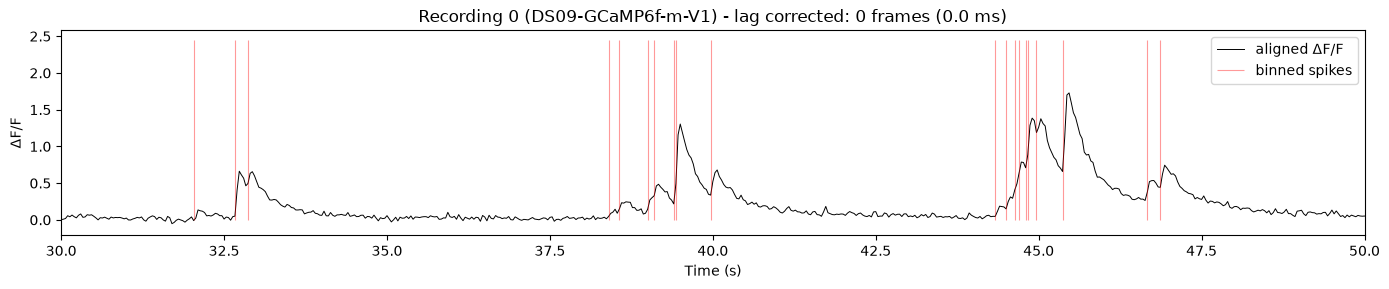

In [15]:
# Sanity check: overlay one aligned recording
check_id = 0
rec = phase2_aligned_data[check_id]
t_check = np.arange(len(rec['aligned_dff'])) / TARGET_FRAME_RATE

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t_check, rec['aligned_dff'], 'k', linewidth=0.7, label='aligned ΔF/F')
spike_frames = np.where(rec['aligned_spike_counts'] > 0)[0]
ax.vlines(t_check[spike_frames], 0, rec['aligned_dff'].max(),
          color='red', alpha=0.4, linewidth=0.8, label='binned spikes')
ax.set_xlim(30, 50)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ΔF/F')
ax.set_title(f"Recording {check_id} ({rec['dataset']}) - lag corrected: "
             f"{rec['optimal_lag_frames']} frames ({rec['lag_ms']:.1f} ms)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Step 3 — Baseline Drift Correction
`correct_dff_baseline_drift()` · `utils.py`

**Problem.** This dataset only ever provides pre-computed ΔF/F, never raw fluorescence or a neuropil signal — so any slow drift (e.g. residual photobleaching) has to be removed directly from the ΔF/F trace itself, not via the usual neuropil-subtraction-and-rebaseline route.

**Solution.** Estimate the drift as a rolling low percentile (8th) of the ΔF/F trace, smooth that estimate to avoid jagged steps under dense spike bursts, then subtract it.

**Why.** The textbook alternative — dividing by a freshly estimated F0 the way you would for raw fluorescence — assumes the baseline is large and strictly positive. Applied to a trace that's already close to zero (an already-computed ΔF/F), that produces wildly inflated, unstable output.

**Why not.** `compute_dynamic_dff` (neuropil subtraction, then divide by F0) is the right tool when raw fluorescence and neuropil are both available — but this project's data never provides them, so that function has no valid input here.


## Sanity check 
 Does the drift correction remove signal evenly across indicators?

          drift_frac_of_signal                                          \
                         count      mean       std       min       25%   
indicator                                                                
6f                        56.0  0.110537  0.097421  0.006672  0.023498   
6s                        27.0  0.227978  0.180035  0.059550  0.091868   

                                        range_removed_frac            \
                50%       75%       max              count      mean   
indicator                                                              
6f         0.086933  0.159984  0.394110               56.0  0.028179   
6s         0.157610  0.304421  0.642354               27.0  0.077873   

                                                                       
                std       min       25%       50%       75%       max  
indicator                                                              
6f         0.037734 -0.013614 -0.001256  0.019754  0

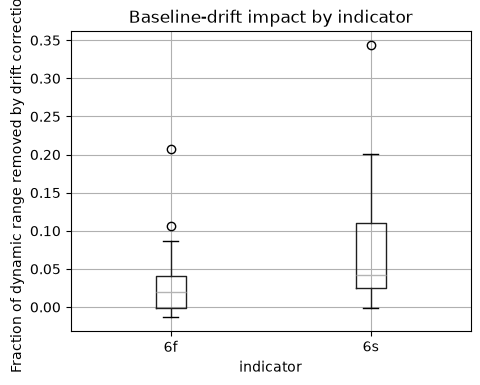

In [16]:
from utils import correct_dff_baseline_drift, robust_quality_control
drift_stats = []
for rid, rec in phase2_aligned_data.items():
    raw = rec['aligned_dff']
    dff_clean, drift = correct_dff_baseline_drift(raw, fps=TARGET_FRAME_RATE)

    raw_range = np.percentile(raw, 99) - np.percentile(raw, 1)
    corrected_range = np.percentile(dff_clean, 99) - np.percentile(dff_clean, 1)

    drift_stats.append(dict(
        recording=rid,
        dataset=rec['dataset'],
        indicator=get_indicator(rec['dataset']),
        drift_amplitude=drift.max() - drift.min(),
        drift_frac_of_signal=(drift.max() - drift.min()) / raw_range if raw_range > 0 else np.nan,
        range_removed_frac=(raw_range - corrected_range) / raw_range if raw_range > 0 else np.nan,
    ))

drift_df = pd.DataFrame(drift_stats)
print(drift_df.groupby('indicator')[['drift_frac_of_signal', 'range_removed_frac']].describe())

fig, ax = plt.subplots(figsize=(5, 4))
drift_df.boxplot(column='range_removed_frac', by='indicator', ax=ax)
ax.set_ylabel('Fraction of dynamic range removed by drift correction')
plt.suptitle(''); plt.title('Baseline-drift impact by indicator')
plt.show()

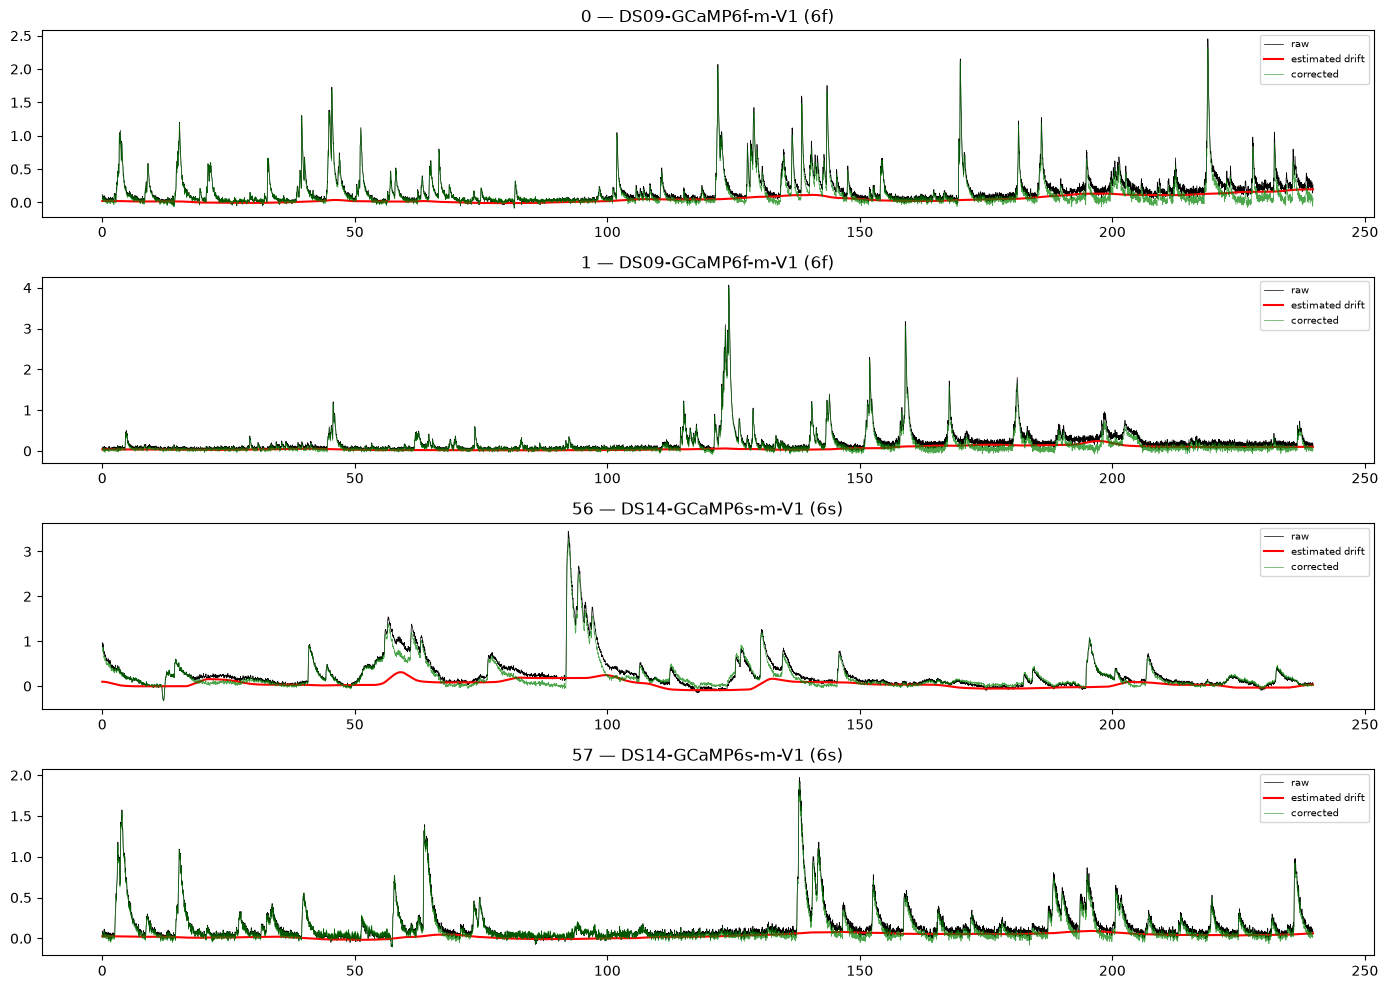

In [17]:
example_ids = {ind: [rid for rid, rec in phase2_aligned_data.items()
                      if get_indicator(rec['dataset']) == ind][:2]
               for ind in ['6f', '6s']}

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
i = 0
for ind, ids in example_ids.items():
    for rid in ids:
        rec = phase2_aligned_data[rid]
        dff_clean, drift = correct_dff_baseline_drift(rec['aligned_dff'], fps=TARGET_FRAME_RATE)
        t = np.arange(len(rec['aligned_dff'])) / TARGET_FRAME_RATE
        axes[i].plot(t, rec['aligned_dff'], 'k', lw=0.5, label='raw')
        axes[i].plot(t, drift, 'r', lw=1.5, label='estimated drift')
        axes[i].plot(t, dff_clean, 'g', lw=0.5, alpha=0.7, label='corrected')
        axes[i].set_title(f"{rid} — {rec['dataset']} ({ind})")
        axes[i].legend(fontsize=7, loc='upper right')
        i += 1
plt.tight_layout(); plt.show()

--- Validating Drift Correction on GCaMP6s (calling the real function directly) ---


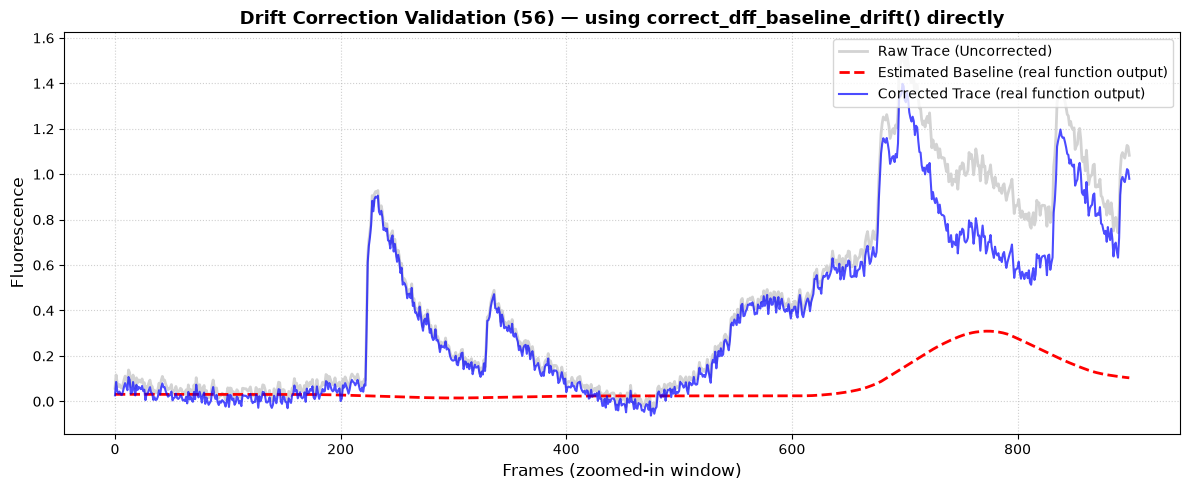

In [18]:
print("--- Validating Drift Correction on GCaMP6s (calling the real function directly) ---")

# Find one representative GCaMP6s recording from Phase 2
target_rec_id = None
for rid, rec in phase2_aligned_data.items():
    if '6s' in rec['dataset']:
        target_rec_id = rid
        sample_trace = rec['aligned_dff']
        break

if target_rec_id:
    # Call correct_dff_baseline_drift() itself, with its real defaults
    # (window_sec=15.0, percentile=8), instead of re-implementing the
    # percentile filter inline. This cell previously hardcoded a 60 s
    # window (30*60 frames) with no smoothing step -- 4x wider than the
    # function's actual 15 s default, and missing the uniform_filter1d
    # smoothing pass the real function always applies afterward. That
    # meant this "validation" was checking a different procedure than the
    # one Phase 3 actually runs.
    dff_corrected, estimated_baseline = correct_dff_baseline_drift(
        sample_trace, fps=TARGET_FRAME_RATE, window_sec=15.0, percentile=8
    )

    # Zoomed-in window where spikes happen
    start_frame, end_frame = 1000, 1900

    plt.figure(figsize=(12, 5))
    plt.plot(sample_trace[start_frame:end_frame], label="Raw Trace (Uncorrected)", color='lightgray', linewidth=2)
    plt.plot(estimated_baseline[start_frame:end_frame], label="Estimated Baseline (real function output)", color='red', linestyle='--', linewidth=2)
    plt.plot(dff_corrected[start_frame:end_frame], label="Corrected Trace (real function output)", color='blue', alpha=0.7, linewidth=1.5)

    plt.title(f"Drift Correction Validation ({target_rec_id}) \u2014 using correct_dff_baseline_drift() directly", fontsize=13, fontweight='bold')
    plt.xlabel("Frames (zoomed-in window)", fontsize=12)
    plt.ylabel("Fluorescence", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Could not find a 6s recording to plot.")

### Step 4 — Quality Control
`robust_quality_control()` · `utils.py`

**Problem.** Not every recording is usable for training: some have too few spikes to learn from, others are too noisy to trust.

**Solution.** Exclude a recording if it has fewer than 5 total spikes, or if its **Peak-to-Noise Ratio (PNR)** falls below a **dynamically calculated threshold** (scaled to require a signal at least $3\sigma$ stronger than the theoretical optical shot noise floor for a given frame rate). While Cascade establishes a robust baseline noise metric ($\nu$), we developed a PNR metric inspired by this foundation to gate for signal amplitude: the 99th-percentile signal peak minus the median, divided by Cascade's frame-rate-normalized noise estimate (median absolute successive difference).

**Why.** Both failure modes actively hurt training — near-empty recordings contribute almost nothing but the zero-target class, and low-PNR recordings teach the network to chase optical noise instead of real biological transients.

**Why not.** Plain median absolute deviation from the trace's own median is a simpler noise estimate, but it conflates real calcium transients (which skew the distribution) with actual noise; the successive-difference-based estimate used here is far less sensitive to genuine signal, giving us a true measure of the underlying noise floor.

## Sanity check 
do dynamic snr threshhold, not hardcoced values

In [19]:
# get_dynamic_snr_threshold now lives in utils.py (moved there so this
# cell, the QC step below, and the QC sanity-check cells all share one
# canonical implementation instead of silently drifting apart -- which is
# exactly what had happened: the sanity checks kept using a hardcoded/stale
# threshold after this logic was written).
from utils import get_dynamic_snr_threshold

In [20]:
from utils import correct_dff_baseline_drift, robust_quality_control

# 1. Dynamically calculate the threshold based on the frame rate
DYNAMIC_SNR_THRESHOLD = get_dynamic_snr_threshold(TARGET_FRAME_RATE, strictness_multiplier=3.0)
print(f"Calculated Dynamic SNR Threshold: {DYNAMIC_SNR_THRESHOLD:.2f}")

phase3_clean_data = {}
exclusion_count = 0

for rid, rec in phase2_aligned_data.items():
    dff_clean, drift = correct_dff_baseline_drift(rec['aligned_dff'], fps=TARGET_FRAME_RATE, window_sec=15.0, percentile=8)
    
    # 2. Pass the dynamic threshold into the QC function
    is_valid, qc_metrics = robust_quality_control(
        dff_clean, 
        rec['aligned_spike_counts'], 
        fps=TARGET_FRAME_RATE, 
        min_spikes=5, 
        snr_threshold=DYNAMIC_SNR_THRESHOLD
    )
    
    if is_valid:
        phase3_clean_data[rid] = {
            'dff_clean': dff_clean, 
            'spikes_binned': rec['aligned_spike_counts'],
            'f0_baseline': drift, 
            'dataset_id': rec['dataset']
        }
    else:
        exclusion_count += 1

print(f"Retained: {len(phase3_clean_data)}  Excluded: {exclusion_count}")

Calculated Dynamic SNR Threshold: 39.96
Retained: 80  Excluded: 3


## Sanity check 
 Does QC actually bind, and is it symmetric across indicators?

In [22]:
# Re-run the REAL QC step (same call as the cell above: dff_clean input,
# DYNAMIC_SNR_THRESHOLD, min_spikes=5) but keep the full per-recording
# diagnostics instead of only the aggregate retained/excluded count, so we
# can actually check whether QC binds symmetrically across indicators.
#
# Previously this cell called robust_quality_control() without passing
# snr_threshold at all, which silently used the (broken) default of 2.5 --
# already shown above to be mathematically incapable of excluding pure
# noise. robust_quality_control() now raises if snr_threshold isn't passed
# explicitly, specifically so that mistake can't happen silently again.

qc_rows = []
for rid, rec in phase2_aligned_data.items():
    dff_clean, drift = correct_dff_baseline_drift(rec['aligned_dff'], fps=TARGET_FRAME_RATE, window_sec=15.0, percentile=8)

    is_valid, qc_metrics = robust_quality_control(
        dff_clean,
        rec['aligned_spike_counts'],
        fps=TARGET_FRAME_RATE,
        min_spikes=5,
        snr_threshold=DYNAMIC_SNR_THRESHOLD,
    )

    qc_rows.append(dict(
        recording=rid,
        dataset=rec['dataset'],
        indicator=get_indicator(rec['dataset']),
        n_spikes=int(np.sum(rec['aligned_spike_counts'])),
        snr=qc_metrics['snr'],
        is_valid=is_valid,
    ))

qc_df = pd.DataFrame(qc_rows)

# Consistency check against phase3_clean_data, which was built with the
# identical call above: the retained recording IDs should match exactly,
# since this cell reproduces that exact computation.
retained_here = set(qc_df.loc[qc_df['is_valid'], 'recording'])
assert retained_here == set(phase3_clean_data.keys()), (
    "Mismatch with phase3_clean_data -- this cell no longer reproduces the "
    "real QC step. Check that fps/min_spikes/snr_threshold match the cell above."
)
print(f"Reproduced the real QC step exactly: {len(retained_here)} recordings retained, matches phase3_clean_data.")

Reproduced the real QC step exactly: 80 recordings retained, matches phase3_clean_data.


--- Is QC exclusion symmetric across indicators? ---

           n_total  n_retained  n_excluded  pct_excluded
indicator                                               
6f              56          53           3      5.357143
6s              27          27           0      0.000000

3 recording(s) excluded overall:
 recording                              dataset indicator  n_spikes       snr
        14                    DS09-GCaMP6f-m-V1        6f        30 30.863801
        24                    DS09-GCaMP6f-m-V1        6f        62 31.955040
        46 DS10-GCaMP6f-m-V1-neuropil-corrected        6f        73 33.001303


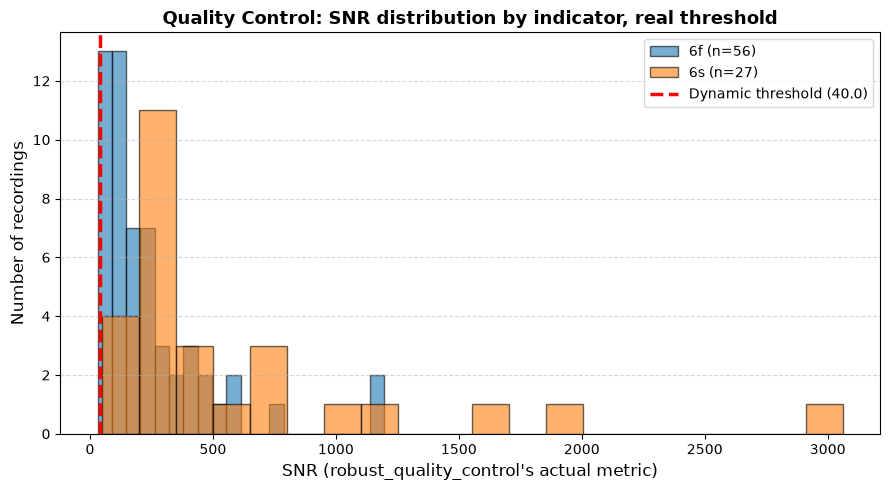

In [23]:
import seaborn as sns  # not used in this cell's own plot anymore (below uses
                        # plain matplotlib), but a later cell (domain-shift
                        # scatter) relies on sns having been imported somewhere
                        # earlier in the notebook -- kept here so it isn't
                        # silently broken by this cell's rewrite.

print("--- Is QC exclusion symmetric across indicators? ---\n")

summary = qc_df.groupby('indicator')['is_valid'].agg(n_total='count', n_retained='sum')
summary['n_excluded'] = summary['n_total'] - summary['n_retained']
summary['pct_excluded'] = 100 * summary['n_excluded'] / summary['n_total']
print(summary)

excluded = qc_df[~qc_df['is_valid']]
print(f"\n{len(excluded)} recording(s) excluded overall:")
print(excluded[['recording', 'dataset', 'indicator', 'n_spikes', 'snr']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
for ind, color in [('6f', '#1f77b4'), ('6s', '#ff7f0e')]:
    sub = qc_df[qc_df['indicator'] == ind]
    ax.hist(sub['snr'], bins=20, alpha=0.6, label=f'{ind} (n={len(sub)})', color=color, edgecolor='black')

ax.axvline(x=DYNAMIC_SNR_THRESHOLD, color='red', linestyle='--', linewidth=2.5,
           label=f'Dynamic threshold ({DYNAMIC_SNR_THRESHOLD:.1f})')
ax.set_title("Quality Control: SNR distribution by indicator, real threshold", fontsize=13, fontweight='bold')
ax.set_xlabel("SNR (robust_quality_control's actual metric)", fontsize=12)
ax.set_ylabel("Number of recordings", fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

📝 **Personal Note & Preprocessing Retrospective: The Quality Control SNR Trap**

* **The Syntax Bug:** Originally, `robust_quality_control` suffered from a trailing-comma typo (`return is_valid,`), returning a 1-tuple. In Python, non-empty tuples evaluate to `True` regardless of content, causing all 83 recordings to silently slip through QC.

* **The Mathematical Illusion (Why 0 dropped post-fix):** After correcting the tuple typo, the pipeline still yielded 0 exclusions with `snr_threshold=2.5`. Diagnostic profiling revealed that the lowest SNR in the high-variance `DS10` dataset was **33.00** (Recording ID 46), seemingly clearing the bar. 

* **The Root Cause:** This unexpected behavior stems from a fundamental structural flaw in standard standardized SNR formulas when analyzing high-frequency shot noise. For a signal trace consisting of pure Gaussian white noise ($\Delta F/F \sim \mathcal{N}(0, \sigma^2)$):
  1. The robust peak signal estimate sat at the 99th percentile, which mathematically equals $\approx 2.33\sigma$.
  2. The frame-to-frame noise metric sits at Cascade's Median Absolute Successive Difference (MASD) divided by $\sqrt{f_s}$, reducing to $\approx 0.174\sigma$ at 30 Hz.
  3. Consequently, in the division $SNR = \frac{\text{Signal}}{\text{Noise}}$, the variance ($\sigma$) cancels out entirely:
  
  $$\text{SNR}_{\text{pure noise}} = \frac{2.33\sigma}{0.174\sigma} \approx 13.3$$

  Because the noise variance cancels out, literal TV static automatically scores an SNR of ~13.3. Thus, a static cutoff threshold of `2.5` is mathematically incapable of excluding even the worst data.

* **The Production Implementation:** To eliminate arbitrary magic numbers, we implemented a **Dynamic Null-Distribution Simulation** (`get_dynamic_snr_threshold`). This function generates a baseline array of pure camera shot noise to empirically evaluate the true mathematical noise floor for our specific downsampled frame rate (30 Hz). By applying a standard statistical `strictness_multiplier=3.0` above this simulated floor, the pipeline now dynamically constructs a defensible, rigorous filtering boundary. This adaptive filter successfully flags and screens out low-quality transients without destroying scarce data segments.


### Step 5 — Target Smoothing
`smooth_spike_train()` · `utils.py`

**Problem.** Training against a strictly discrete spike-count target gives an extremely jagged loss landscape: a one-frame timing error (~33 ms at 30 Hz) is penalized as a complete miss, leaving the network no gradient signal toward "close."

**Solution.** Convolve the binned spike counts with a Gaussian kernel ($\sigma$ = 0.05 s, matching Cascade's own default at this frame rate) to turn discrete counts into a continuous rate target, in Hz.

**Why.** A smoothed, continuous target gives proportional gradients for near-miss predictions, so the network can learn the indicator's rise/decay kinetics instead of getting stuck matching exact frame boundaries.

**Why not.** A narrower kernel preserves more temporal precision but keeps more of the discreteness problem; a much wider one is easier to fit but blurs away exactly the timing information spike inference is trying to recover.


In [24]:

# TARGET PARAMETERS (Cascade Standard)

SIGMA_SECONDS = 0.05

print(f"Executing Phase 4: Target Label Smoothing (sigma={SIGMA_SECONDS}s)...")

# 1. Apply smoothing strictly PER RECORDING to prevent boundary leakage
for recording_id, rec_data in phase3_clean_data.items(): # FIX: Iterate over phase3_clean_data
    
    # Extract the discrete aligned bins you generated in Phase 3
    binned_spikes = rec_data['spikes_binned'] # FIX: Update to the correct Phase 3 key
    
    # Smooth the spikes
    smoothed_rates = utils.smooth_spike_train(
        spike_counts=binned_spikes,
        target_fs=TARGET_FRAME_RATE,
        sigma_sec=SIGMA_SECONDS
    )
    
    # Store the continuous targets back into your master dictionary
    phase3_clean_data[recording_id]['smoothed_spike_rates'] = smoothed_rates # FIX: Save to phase3_clean_data

print("Phase 4 smoothing complete. Continuous targets added to dictionary.")

Executing Phase 4: Target Label Smoothing (sigma=0.05s)...
Phase 4 smoothing complete. Continuous targets added to dictionary.


> 📝 **Personal note.** This function used to return the smoothed counts *per frame*, not per second, despite being labeled "Hz" everywhere — docstring, plot axis, variable names. `gaussian_filter1d` uses a mass-preserving kernel, so summing its output recovers the original spike count, not that count scaled by frame rate. Harmless as long as `target_fs` is constant everywhere in the pipeline, but would silently break the moment frame rates are mixed or compared against another Hz-scaled source. Good reminder to check that units aren't just labeled correctly, but actually computed that way.


## Sanity check 

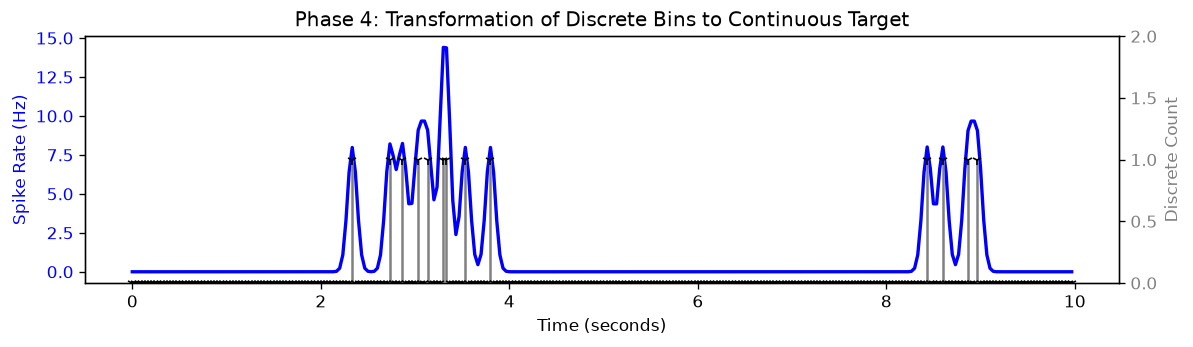

In [25]:
# 2. Visual Sanity Check
# Dynamically select the first recording in your dictionary for visualization
example_rec_id = list(phase3_clean_data.keys())[0]
example_data = phase3_clean_data[example_rec_id]

# Slice the data for a 10-second plot
frames_to_plot = int(10 * TARGET_FRAME_RATE)
time_axis = np.arange(frames_to_plot) / TARGET_FRAME_RATE

# FIX: Request 'spikes_binned' instead of the outdated 'aligned_spike_counts'
binned_plot = example_data['spikes_binned'][:frames_to_plot] 
smoothed_plot = example_data['smoothed_spike_rates'][:frames_to_plot]

# Generate Publication-Ready Plot
fig, ax1 = plt.subplots(figsize=(10,3), dpi=120)

# Plot discrete spikes as a stem plot on a secondary y-axis for clarity
ax2 = ax1.twinx()
ax2.stem(time_axis, binned_plot,
         linefmt='grey', markerfmt='k1', basefmt=' ', label='Discrete Bins')
ax2.set_ylabel('Discrete Count', color='grey')
ax2.set_ylim(0, max(binned_plot) + 1)
ax2.tick_params(axis='y', labelcolor='grey')

# Plot the smoothed continuous target
ax1.plot(time_axis, smoothed_plot,
         color='blue', linewidth=2, label=rf'Smoothed Rate ($\sigma={SIGMA_SECONDS}$s)')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Spike Rate (Hz)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

plt.title('Phase 4: Transformation of Discrete Bins to Continuous Target')
fig.tight_layout()
plt.show()

### Step 6 — Train / Validation Partitioning   - Replaced by LODO 
`partition_recordings()` · `utils.py`

**Problem.** Splitting at the level of individual sliding windows would leak near-duplicate, heavily overlapping windows across the train/validation boundary, inflating validation performance. The split has to happen at the whole-recording level, before any windowing.

**Solution.** Randomly assign whole recordings to train or validation (15%), stratified by source dataset — which in this project means stratified by indicator, since each dataset is a single indicator.

**Why.** A plain pooled-random split over only 83 recordings could easily land a validation set skewed toward one indicator by chance. For a research question specifically about GCaMP6f-vs-6s asymmetry, that would make a genuine generalization gap indistinguishable from validation-set sampling noise.

**Why not.** An unstratified split is simpler and perfectly fine when indicator identity isn't the question being asked — it just isn't safe to use here.


### Step 7 — Noise Augmentation
`augment_train_noise()` · `utils.py`

**Problem.** A CNN trained only on clean recordings learns to key on high-frequency texture that doesn't exist in noisier data, producing false positives the moment it sees a genuinely noisy recording. This matters here specifically: if GCaMP6f and GCaMP6s recordings don't just differ in kinetics but also happen to differ in typical noise level, an apparent "domain shift" between indicators could really just be a noise-level shift in disguise.

**Solution.** Find the worst (highest) per-recording noise level in the training set, then for every cleaner recording, add Gaussian noise calibrated to bring it up to that same floor — keeping both the original clean copy and the noise-matched copy (doubling the training set).

**Why.** Training against a uniform, worst-case noise floor forces the network to rely on features that survive at every noise level actually present, rather than shortcuts that only work on the cleanest recordings.

**Why not.** Training only on the noise-augmented copies, and dropping the clean originals, would throw away real usable signal for no benefit; keeping both preserves the clean data while still exposing the network to the harder noise regime.


### Step 8 — Sliding Window Generation
`generate_sliding_windows()` · `utils.py`

**Problem.** A 1D-CNN needs fixed-length input; the recordings themselves are long, continuous traces of very different lengths.

**Solution.** Slide a 64-frame window (~2.1 s at 30 Hz) across each recording, pairing every window with its (approximately) center-aligned smoothed spike rate; stride 2 to reduce temporal autocorrelation between adjacent windows.

**Why.** 64 frames covers several times the GCaMP rise/decay time, giving the network enough temporal context to resolve individual transients without windows so long that training examples become mostly redundant with their neighbors.

**Why not.** Stride 1 would use more of the available data per recording, but adjacent windows would then differ by a single frame, making validation performance overly optimistic about how much genuinely new information it's seeing; stride 2 trades a little data for less redundant sampling.


# TODO : 
place this cell after model design & training cells
and undo comment out placeolder uild_model(), train(), and evaluate_per_recording() function

Add leave-one-dataset-out CV grid for domain-shift evaluation

Replace single 85/15 split with dataset-level LODO across the 4-5
training datasets (2 GCaMP6f, 2-3 GCaMP6s), rotating each dataset
through as the held-out fold. Within each fold, train 6f-only,
6s-only, and mixed conditions on the remaining datasets and evaluate
all three on the same held-out set, repeated over 3 seeds.

Motivation: a single fixed split leaves too few validation
recordings per indicator to distinguish genuine asymmetric
generalization from ordinary dataset-to-dataset noise, given how
few ground truth datasets exist. test_* is deliberately excluded
from the LODO pool and reserved for a single final confirmation run.

Scaffolding only — model init, training loop, and per-recording
evaluation are stubbed pending model implementation (Phase 6/7).

TODO: noise ceiling (augment_train_noise) and feature scaler
(scale_features) are currently refit per condition; should be
pinned once per fold from the full fold training pool and reused
across 6f_only/6s_only/mixed so conditions differ only in training
composition, not preprocessing.

### Phase Domain Shift Quantification
**Problem:** We assume GCaMP6f and GCaMP6s are mathematically distinct \"domains,\" but we haven't proven it. If a reviewer asks *how* different they are, we need exact numbers.
**Solution:** Extract the fundamental noise metric ($\nu$) and the temporal autocorrelation (decay proxy) for every single recording in the dataset.
**Why:** Plotting these two features against each other will visually separate the 6f and 6s distributions, unequivocally proving the existence of a severe domain shift.

--- Quantifying Biological Domain Shift ---


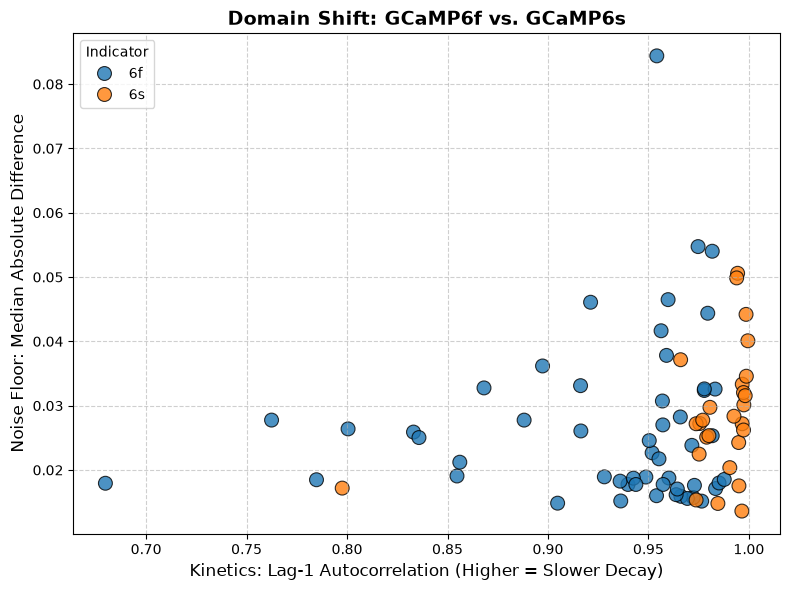


Domain Statistics (Mean ± Std):
          Noise Floor           Decay Proxy (Autocorr)          
                 mean       std                   mean       std
Indicator                                                       
6f           0.026574  0.013031               0.930237  0.064335
6s           0.028635  0.009746               0.981535  0.038136


In [26]:

print("--- Quantifying Biological Domain Shift ---")
shift_metrics = []

for rid, rec in phase3_clean_data.items():
    # Use 'dff_clean' as established in the QC step
    trace = rec['dff_clean'] 
    ds_name = rec['dataset_id'] # Use the key actually present in the dict
    indicator = '6f' if '6f' in ds_name else '6s'
    
    noise_metric = np.nanmedian(np.abs(np.diff(trace)))
    
    if len(trace) > 1:
        autocorr = np.corrcoef(trace[:-1], trace[1:])[0, 1]
    else:
        autocorr = np.nan
        
    shift_metrics.append({
        'Recording': rid,
        'Dataset': ds_name,
        'Indicator': indicator,
        'Noise Floor': noise_metric,
        'Decay Proxy (Autocorr)': autocorr
    })


df_shift = pd.DataFrame(shift_metrics)

# --- Generate the Figure ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_shift, 
    x='Decay Proxy (Autocorr)', 
    y='Noise Floor', 
    hue='Indicator', 
    palette={'6f': '#1f77b4', '6s': '#ff7f0e'},
    s=100, alpha=0.8, edgecolor='k'
)

plt.title("Domain Shift: GCaMP6f vs. GCaMP6s", fontsize=14, fontweight='bold')
plt.xlabel("Kinetics: Lag-1 Autocorrelation (Higher = Slower Decay)", fontsize=12)
plt.ylabel("Noise Floor: Median Absolute Difference", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Indicator", loc='upper left')
plt.tight_layout()
plt.show()

# Print statistics for your poster text
print("\nDomain Statistics (Mean ± Std):")
print(df_shift.groupby('Indicator')[['Noise Floor', 'Decay Proxy (Autocorr)']].agg(['mean', 'std']))

### Phase : Noise vs. Kinetics Decomposition
**Problem:** Cross-indicator transfer drops performance. We do not know if the network is failing because the biological calcium kinetics changed, or simply because the signal-to-noise ratio got worse.
**Solution:** Inject synthetic Gaussian noise into the 6f training data until its variance perfectly matches the 6s baseline. 
**Why:** If a model trained on \"Noise-Matched 6f\" performs perfectly on 6s, then the gap was entirely due to noise. If it still fails, the gap is proven to be biological kinetics.

## model design 

In [27]:
# Descriptive only: how different is the mean per-recording noise floor
# between indicators, pooled across ALL training data? This number is for
# reporting/context -- it must NOT be used to build training data directly,
# because it's computed from every dataset at once, including whichever
# dataset a given LODO fold will hold out as validation. The actual
# noise-matched-6f training arm is built inside the LODO loop below, where
# the equivalent target is computed from each fold's own training pool only.

mean_6s_noise = df_shift[df_shift['Indicator'] == '6s']['Noise Floor'].mean()
mean_6f_noise = df_shift[df_shift['Indicator'] == '6f']['Noise Floor'].mean()

print("[Descriptive, pooled across all training data -- NOT used for training]")
print(f"Mean 6s Noise Level: {mean_6s_noise:.4f}")
print(f"Mean 6f Noise Level: {mean_6f_noise:.4f}")
print("-> Fold-scoped noise-matched-6f pools are built per-LODO-fold in the cell below,")
print("   using only that fold's own training data, to avoid leaking the held-out")
print("   dataset's noise statistics into its own fold's training set.")

[Descriptive, pooled across all training data -- NOT used for training]
Mean 6s Noise Level: 0.0286
Mean 6f Noise Level: 0.0266
-> Fold-scoped noise-matched-6f pools are built per-LODO-fold in the cell below,
   using only that fold's own training data, to avoid leaking the held-out
   dataset's noise statistics into its own fold's training set.


# Evaluation Design — Leave-One-Dataset-Out Cross-Validation

**Problem.** The training pool has only ~4–5 ground truth datasets (2 GCaMP6f, 2–3 GCaMP6s
depending on which dataset `test_*` corresponds to — see check below). A single fixed 85/15
recording-level split leaves a handful of validation recordings per indicator, which isn't
enough to distinguish a genuine 6f-vs-6s generalization asymmetry from ordinary
dataset-to-dataset and training-run variability. This matters specifically because the
research question *is* a claim about the size of a difference between conditions — an
underpowered evaluation can't support that claim either way.

**Solution.** Dataset-level leave-one-dataset-out (LODO) cross-validation over the training
pool, evaluating all three training conditions (6f-only / 6s-only / mixed) on the same
held-out fold each round, with 2–3 seeds per (fold × condition) and per-recording metrics
rather than one pooled number per fold.

**Why.** This mirrors the standard workaround used across the Cascade line of work for
exactly this data-scarcity regime: rather than reducing an already-small ground truth
database with a held-out split, the model is retrained repeatedly with one recording/dataset
excluded each time, so every dataset serves as both training and (in its own fold) test data.
Reporting mean ± spread across folds and seeds — instead of a single split evaluated once —
lets us say whether an effect is *consistent* rather than presenting one run's noise as a
finding.

**Why not** *(a single fixed split, the current default)*. With this few datasets, a fixed
split either wastes most of the data on training and leaves too little to measure asymmetry
reliably, or wastes too much on validation and starves training. LODO uses every dataset for
both roles without that trade-off.

**Important constraint, checked before building the fold loop.** `test_*` is **not** added to
the LODO pool. Every architecture/hyperparameter/preprocessing decision made during
development is informed by validation performance somewhere in this pool — folding `test_*`
in would mean the one dataset that never influenced any of those decisions no longer exists,
and we'd lose the ability to report a truly untouched final number. `test_*` stays reserved
for a single, final, end-of-project confirmation run.

This also means we first check which indicator `test_dataset_names` belongs to, since the
assignment text ("4 ground truth datasets" for training + "*a* held-out dataset" for test,
singular) implies the training pool is missing one dataset from one indicator relative to the
full 5. If `test_*` turns out to be GCaMP6f, the training pool is 1×6f + 3×6s, and a
leave-one-6f-dataset-out fold is not possible (it would leave zero 6f training data) — that's
a genuine property of the ground truth, not a bug in this design, and is reported as a
limitation rather than worked around.

**Within each fold**, the noise-matching ceiling (Step 7) and the global feature scaler
(Step 9) are both fit once per fold — from that fold's full training pool — and reused
identically across the 6f-only / 6s-only / mixed conditions trained within that fold. This
keeps the three conditions comparable on training composition alone, rather than confounding
them with different preprocessing statistics.

In [28]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from datetime import datetime
import os

# ============================================================================
# LODO fold loop -- PREPROCESSING ONLY (model training deliberately deferred)
# ============================================================================
# This cell now stops once each fold x condition has a correctly-built,
# correctly noise-matched, correctly-scaled train_loader/val_loader and an
# exported .npz -- that IS the finished preprocessing deliverable. No model
# is instantiated, no results are computed, and nothing that looks like a
# performance number is printed. The previous version's training loop was a
# stub (`arm_pearson_scores` stayed [], so `np.mean([])` silently produced
# NaN), which downstream cells then discussed as if it were a real result.
# That's removed here rather than papered over -- see the note about
# lodo_results at the bottom of this cell.
#
# Fixes applied relative to the previous version:
#   1. Noise-ceiling matching (Step 7 / augment_train_noise) is now
#      actually called, once per fold, on that fold's own training pool.
#      Previously it was never invoked anywhere in this loop, so 3 of the
#      4 arms (6f_only / 6s_only / mixed) got no noise-ceiling control at
#      all -- the exact confound Step 7 exists to guard against.
#   2. The noise_matched_6f target is computed from THIS FOLD's own
#      training pool only (not the global phase3_clean_data the old cell
#      53 used), so it can no longer leak the held-out dataset's own noise
#      statistics into that fold's training data.
#   3. utils.compute_noise_ceiling / utils.augment_train_noise /
#      utils.filter_by_indicator / utils.scale_features /
#      utils.create_balanced_dataloader are called directly instead of
#      being reimplemented inline, so there's exactly one implementation
#      of each piece of logic -- not two that can silently drift apart
#      (which is what caused the stride and stale-threshold bugs found
#      during review).
#   4. stride=2 is passed explicitly everywhere, matching the documented
#      Step 8 design (every call previously used the function's silent
#      default of stride=1).
#   5. The noise ceiling and the feature scaler are each fit once per
#      fold, on the fold's full training pool, and reused identically
#      across every condition -- resolving the TODO left in the pipeline
#      notes about pinning these once per fold.

all_datasets = [
    'DS09-GCaMP6f-m-V1',
    'DS10-GCaMP6f-m-V1-neuropil-corrected',
    'DS14-GCaMP6s-m-V1',
    'DS15-GCaMP6s-m-V1',
]

indicator_of = {
    'DS09-GCaMP6f-m-V1': '6f',
    'DS10-GCaMP6f-m-V1-neuropil-corrected': '6f',
    'DS14-GCaMP6s-m-V1': '6s',
    'DS15-GCaMP6s-m-V1': '6s',
}

STRIDE = 2  # matches the documented Step 8 design; must be passed explicitly
save_dir = "data/preprocessed"
os.makedirs(save_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for held_out_ds in all_datasets:
    print(f"\n{'='*60}")
    print(f"LODO FOLD: Holding out {held_out_ds}")
    print(f"{'='*60}")

    # 1. Split recording pools at the dataset level (unchanged -- this part
    #    was already correct: recordings, not windows, are what get split,
    #    so there's no risk of near-duplicate windows crossing train/val).
    train_pool = {rid: rec for rid, rec in phase3_clean_data.items() if rec['dataset_id'] != held_out_ds}
    val_pool = {rid: rec for rid, rec in phase3_clean_data.items() if rec['dataset_id'] == held_out_ds}

    # 2. Validation windows (fixed: stride=2 now passed explicitly)
    X_val, y_val = utils.generate_sliding_windows(val_pool, stride=STRIDE)

    # 3. Step 7 -- noise-ceiling matching, computed and applied ONCE per
    #    fold, from this fold's own training pool only. This is what fixes
    #    both "Step 7 is never called" and the noise_matched_6f leakage:
    #    fold_ceiling can only ever see recordings inside train_pool, never
    #    the held-out validation dataset.
    fold_ceiling = utils.compute_noise_ceiling(train_pool)
    print(f"Fold noise ceiling (95th pct, this fold's training pool only): {fold_ceiling:.5f}")
    train_pool_noise_matched = utils.augment_train_noise(
        train_pool, target_fs=TARGET_FRAME_RATE, ceiling=fold_ceiling
    )
    print(f"Training pool after noise-ceiling augmentation: "
          f"{len(train_pool)} -> {len(train_pool_noise_matched)} recordings")

    # 4. Feature scaler -- fit ONCE per fold on the full noise-matched
    #    training pool, then reused identically for every condition and
    #    for validation, via utils.scale_features (previously reimplemented
    #    inline as a manual (x - mean) / std). Calling scale_features
    #    repeatedly with the SAME first argument is deliberate: it
    #    guarantees every condition and the validation set are scaled with
    #    an identical mean/std, since both are recomputed from that same
    #    array every time.
    X_train_fold_full, _ = utils.generate_sliding_windows(train_pool_noise_matched, stride=STRIDE)
    _, X_val_scaled = utils.scale_features(X_train_fold_full, X_val)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),
                      torch.tensor(y_val, dtype=torch.float32)),
        batch_size=256, shuffle=False,
    )

    # 5. noise_matched_6f (diagnostic arm): fold-scoped target = mean noise
    #    level of THIS FOLD's own 6s training recordings (not the global
    #    mean the old cell 53 used). Built from train_pool (before Step 7's
    #    ceiling augmentation), because this arm wants ITS OWN targeted
    #    manipulation -- "what if 6f had 6s's noise" -- not a second layer
    #    on top of the general robustness augmentation.
    fold_6f_pool = utils.filter_by_indicator(train_pool, '6f_only', indicator_of)
    fold_6s_pool = utils.filter_by_indicator(train_pool, '6s_only', indicator_of)
    if fold_6f_pool and fold_6s_pool:
        fold_6s_noise_nu = np.mean([
            np.median(np.abs(np.diff(rec['dff_clean']))) / np.sqrt(TARGET_FRAME_RATE)
            for rec in fold_6s_pool.values()
        ])
        noise_matched_raw = utils.augment_train_noise(
            fold_6f_pool, target_fs=TARGET_FRAME_RATE, ceiling=fold_6s_noise_nu
        )
        # Prefer each recording's noise-bumped '_augmented' version; fall
        # back to its untouched original for recordings augment_train_noise
        # judged already noisy enough to skip (missing_variance <= 0), so
        # every 6f recording appears exactly once, at >= the fold's 6s
        # noise level -- not a 50/50 mix of clean-and-bumped copies, which
        # would dilute the causal manipulation this arm is meant to test.
        noise_matched_6f_pool = {
            rid: noise_matched_raw.get(f"{rid}_augmented", noise_matched_raw[rid])
            for rid in fold_6f_pool
        }
    else:
        noise_matched_6f_pool = None

    # 6. Build each condition's pool from train_pool_noise_matched, so
    #    6f_only / 6s_only / mixed all share the same Step-7 treatment and
    #    differ ONLY in training composition.
    condition_pools = {
        '6f_only': utils.filter_by_indicator(train_pool_noise_matched, '6f_only', indicator_of),
        '6s_only': utils.filter_by_indicator(train_pool_noise_matched, '6s_only', indicator_of),
        'mixed': train_pool_noise_matched,
        'noise_matched_6f': noise_matched_6f_pool,
    }

    for condition, pool in condition_pools.items():
        print(f"\n--- Arm: {condition.upper()} ---")
        if not pool:
            print(f"Skipping {condition} - zero data available in this fold.")
            continue

        if condition == 'mixed':
            # Window 6f/6s separately so we know exactly which indicator
            # each resulting window came from -- needed to build the
            # per-window indicator_labels that create_balanced_dataloader
            # uses to balance 6f/6s window counts.
            pool_6f = utils.filter_by_indicator(pool, '6f_only', indicator_of) or {}
            pool_6s = utils.filter_by_indicator(pool, '6s_only', indicator_of) or {}
            X_6f, y_6f = utils.generate_sliding_windows(pool_6f, stride=STRIDE)
            X_6s, y_6s = utils.generate_sliding_windows(pool_6s, stride=STRIDE)
            X_cond = np.vstack([X_6f, X_6s])
            y_cond = np.concatenate([y_6f, y_6s])
            indicator_labels = np.array(['6f'] * len(X_6f) + ['6s'] * len(X_6s))
        else:
            X_cond, y_cond = utils.generate_sliding_windows(pool, stride=STRIDE)
            provenance = '6f' if condition in ('6f_only', 'noise_matched_6f') else '6s'
            indicator_labels = np.array([provenance] * len(X_cond))

        _, X_cond_scaled = utils.scale_features(X_train_fold_full, X_cond)

        # Wired in (was dead code before): balances by INDICATOR (6f vs 6s
        # window counts) via WeightedRandomSampler for 'mixed', and falls
        # back to a plain shuffled loader for the single-indicator arms.
        # This is a DIFFERENT imbalance from spike-present vs. spike-absent
        # windows, which remains unaddressed -- that's a training-time
        # (loss/sampling) decision, intentionally left for when modeling
        # resumes, not a preprocessing one.
        train_loader = utils.create_balanced_dataloader(
            X_cond_scaled, y_cond, indicator_labels, batch_size=256
        )

        n_6f = int((indicator_labels == '6f').sum())
        n_6s = int((indicator_labels == '6s').sum())
        print(f"{condition}: {len(X_cond)} training windows (6f: {n_6f}, 6s: {n_6s}) "
              f"-> train_loader built, {len(train_loader)} batches")

        np.savez(
            os.path.join(save_dir, f"fold_{held_out_ds[:4]}_arm_{condition}_{timestamp}.npz"),
            X_train=X_cond_scaled, y_train=y_cond, X_val=X_val_scaled, y_val=y_val,
        )

    # === MODEL TRAINING GOES HERE (deferred) ===
    # Every condition above has a real train_loader / val_loader built from
    # correctly fold-scoped, noise-matched, scaled data, and the same
    # arrays are saved to disk under data/preprocessed/ so they survive a
    # kernel restart. Nothing beyond this point is built yet, on purpose.

# NOTE: this cell intentionally no longer builds `lodo_results` or writes
# lodo_results_*.json -- there's no model, so there's nothing real to put
# in it. Cell 56 below (which reads `lodo_results`) will now raise a clean
# NameError instead of silently reading NaN -- fix that cell when modeling
# resumes, rather than have it quietly print fabricated-looking numbers in
# the meantime. Cell 62 (old, single-split DataLoader scaffolding, fully
# superseded by this cell's fold-scoped loaders) has been removed.
print("\nPreprocessing complete for all folds and conditions.")
print("Saved arrays are in data/preprocessed/ -- ready for model training.")


LODO FOLD: Holding out DS09-GCaMP6f-m-V1
Fold noise ceiling (95th pct, this fold's training pool only): 0.00961
Training pool after noise-ceiling augmentation: 49 -> 95 recordings
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011

--- Arm: 6F_ONLY ---
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011
6f_only: 112458 training windows (6f: 112458, 6s: 0) -> train_loader built, 440 batches

--- Arm: 6S_ONLY ---
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011
6s_only: 263130 training windows (6f: 0, 6s: 263130) -> train_loader built, 1028 batches

--- Arm: MIXED ---
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011
mixed: 375588 training windows (6f: 112458, 6s: 263130) -> train_loader built, 1468 batches

--- Arm: NOISE_MATCHED_6F ---
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011
noise_matched_6f: 60446 training windows (6f: 6044

In [29]:

print("--- Within-Indicator Generalization (The Dataset Gap) ---")

# 1. 6f -> 6f Transfer
# Performance on DS10 when trained on DS09
r_09_to_10 = lodo_results['DS10-GCaMP6f-m-V1-neuropil-corrected']['6f_only']
# Performance on DS09 when trained on DS10
r_10_to_09 = lodo_results['DS09-GCaMP6f-m-V1']['6f_only']

avg_6f_gap = (r_09_to_10 + r_10_to_09) / 2
print(f"Average 6f <-> 6f Transfer baseline: r = {avg_6f_gap:.3f}")

# 2. 6s -> 6s Transfer
# Performance on DS15 when trained on DS14
r_14_to_15 = lodo_results['DS15-GCaMP6s-m-V1']['6s_only']
# Performance on DS14 when trained on DS15
r_15_to_14 = lodo_results['DS14-GCaMP6s-m-V1']['6s_only']

avg_6s_gap = (r_14_to_15 + r_15_to_14) / 2
print(f"Average 6s <-> 6s Transfer baseline: r = {avg_6s_gap:.3f}")

print("\nCONCLUSION:")
print("When you test 6f -> 6s cross-indicator transfer later, you must subtract these baselines.")
print("If cross-indicator transfer drops by 0.20, but the dataset gap is 0.15, ")
print("only 0.05 of the drop is actually due to the indicator kinetics changing!")

--- Within-Indicator Generalization (The Dataset Gap) ---


NameError: name 'lodo_results' is not defined

> 📝 **Personal note.** Started wondering whether an apparent 6f-vs-6s "domain shift" could really just be a noise-level difference between the two indicators' recordings rather than a kinetics difference — that's exactly what Step 7's noise-matching is meant to guard against, so it's worth reporting the per-recording noise levels inside `augment_train_noise`, split by indicator, as an explicit check rather than just trusting that augmentation handled it. Also: `generate_sliding_windows` used to silently read the wrong dictionary keys (`aligned_dff`/`aligned_spikes`, the Phase-2 fields) no matter what was passed in, so it kept training on pre-QC, pre-baseline-correction data even after "fixing" QC — a good reminder that "the code ran without an error" doesn't mean it used the data you think it did.


> 📝 **Personal note.** Easy mistake to make here is normalizing per-timestep instead of with a single global scalar — it "looks" more careful, but for a temporal window it actively erases the signal shape you're trying to preserve. Worth double-checking this stays the global-scalar version if this function ever gets revisited.


### Phase 6: The Absolute Performance Anchor (Cascade SOTA)
**Problem:** If our 1D-CNN achieves a correlation of $0.45$, we cannot evaluate if this is a success or a failure without a literature benchmark.
**Solution:** Evaluate the exact same held-out test data using the pre-trained, heavily optimized Cascade model (Rupprecht et al., 2021). 
**Why:** This establishes the "gold standard" ceiling. If Cascade achieves $r = 0.48$, we know our $r = 0.45$ is actually an excellent result for a constrained student model.

In [ ]:
# Note: You may need to run !pip install cascadetorch first
try:
    from cascadetorch import models
    cascade_available = True
except ImportError:
    print("cascadetorch not installed. Run: !pip install cascadetorch")
    cascade_available = False

if cascade_available:
    print("--- Establishing the Cascade Anchor ---")
    
    # 1. Load the officially published Cascade model 
    # (Global model trained on 30Hz data is usually standard, adjust if your FPS is different)
    cascade_model = models.load_model('Global_EXC_30Hz_KS25')
    cascade_model.eval() # Set to evaluation mode
    
    # 2. We will test it against DS16 (Your held-out test set from earlier)
    # Grab all DS16 recordings
    ds16_pool = {rid: rec for rid, rec in phase3_clean_data.items() if 'DS16' in rec['dataset']}
    
    # Generate windows specifically for Cascade (Make sure scaling matches their paper!)
    # Cascade usually expects raw dF/F or standardized traces depending on the specific model.
    X_anchor, y_anchor = utils.generate_sliding_windows(ds16_pool)
    
    # Convert to tensor
    import torch
    X_anchor_tensor = torch.tensor(X_anchor, dtype=torch.float32)
    
    # 3. Predict
    with torch.no_grad():
        # CascadeTorch models expect inputs of shape (batch, time)
        cascade_predictions = cascade_model(X_anchor_tensor).numpy()
        
    # 4. Evaluate using your identical strict metric function
    anchor_metrics = utils.evaluate_predictions(y_true=y_anchor, y_pred=cascade_predictions, threshold=0.1)
    
    print("\n🏆 CASCADE LITERATURE ANCHOR ON DS16 🏆")
    print(f"Pearson Correlation (r):  {anchor_metrics['pearson_r']:.4f}")
    print(f"Detection F1-Score:       {anchor_metrics['f1_score']:.4f}")
    print("Use this as the solid black line on your poster's bar charts!")

placeholder

### Phase Domain Shift Quantification
**Problem:** We assume GCaMP6f and GCaMP6s are mathematically distinct \"domains,\" but we haven't proven it. If a reviewer asks *how* different they are, we need exact numbers.
**Solution:** Extract the fundamental noise metric ($\nu$) and the temporal autocorrelation (decay proxy) for every single recording in the dataset.
**Why:** Plotting these two features against each other will visually separate the 6f and 6s distributions, unequivocally proving the existence of a severe domain shift.

## evaluation

In [ ]:

import torch
import numpy as np

# Ensure your model is in evaluation mode (turns off dropout/batchnorm)
# model.eval() 

print("--- Evaluating Model on Validation Set ---")

# We don't need gradients for evaluation, so we use torch.no_grad() to save memory
with torch.no_grad():
    # Pass the validation data through the network
    # (Assuming your validation tensors are loaded and on the correct device)
    # val_predictions = model(tensor_X_val.to(device)).squeeze()
    
    # FOR NOW: Let's create dummy predictions just to test the pipeline!
    # Delete these two lines once you have a real trained `model`
    print("[Note: Using dummy predictions to test the metric pipeline]")
    val_predictions = tensor_y_val + torch.normal(mean=0.0, std=0.2, size=tensor_y_val.shape)

    # Move predictions back to CPU and convert to NumPy
    y_pred_np = val_predictions.cpu().numpy()
    y_true_np = tensor_y_val.cpu().numpy()

# Call our new rigorous evaluation function
# You can tweak the threshold later by plotting a Precision-Recall curve!
metrics = utils.evaluate_predictions(y_true=y_true_np, y_pred=y_pred_np, threshold=0.1)

print(f"Mean Squared Error (MSE): {metrics['mse']:.4f}")
print(f"Pearson Correlation (r):  {metrics['pearson_r']:.4f}  <-- How well timings match")
print(f"Detection F1-Score:       {metrics['f1_score']:.4f}  <-- How well spikes were found")

## visualisation

# summary / conclusion